## Dependencies

Run the cell below to install all required packages before executing this notebook:

```bash
pip install numpy pandas scikit-learn matplotlib seaborn joblib psutil pyarrow
```

In [1]:
# Install dependencies (uncomment if needed)
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install',
#     'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', 'joblib', 'psutil', 'pyarrow'])

%matplotlib inline

# 05 – Evaluation (Option A — Anomaly Injection)

This notebook demonstrates the full evaluation workflow using **Option A** (synthetic anomaly injection) to produce ground-truth labels, then computes:

- Confusion matrix (TP / FP / TN / FN)
- Precision, Recall, F1-score, False Positive Rate
- ROC curve and AUC-ROC
- Score distribution (normal vs injected anomalies)
- System performance metrics (throughput, latency, CPU, memory)

## Why Option A?

Unsupervised anomaly detectors do not use labels during training, so there is no inherent ground truth in the raw logs.  
Option A **injects** known attack patterns (DoS spikes, brute-force bursts, scanner behaviour, data-exfil patterns) into the dataset, creating explicit 0/1 labels.  
This mirrors the project objective: *"validated against known attack patterns within the dataset."*


In [2]:
import sys, pathlib, warnings
ROOT = pathlib.Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")


In [3]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
)
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import time, psutil, json

RANDOM_STATE = 42
INJECTION_FRACTION = 0.08
CONTAMINATION = INJECTION_FRACTION

FEAT_FILE = ROOT / "data" / "processed" / "features.parquet"
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)
MODELS_DIR = ROOT / "models"

FEAT_COLS = [
    "requests_per_hour", "error_rate", "unique_endpoints",
    "avg_bytes_sent", "post_ratio", "is_off_hours", "is_weekend", "has_scanner_ua"
]


In [4]:
# ── Load features ─────────────────────────────────────────────────────────────
feat_df = pd.read_parquet(str(FEAT_FILE))
X_raw = feat_df[FEAT_COLS].to_numpy(dtype=float)
print(f"Loaded {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features")


Loaded 159 rows × 8 features


In [5]:
# ── Option A: inject anomalies ────────────────────────────────────────────────
rng = np.random.default_rng(RANDOM_STATE)

n = len(X_raw)
n_inject = max(1, int(n * INJECTION_FRACTION))
inject_idx = rng.choice(n, size=n_inject, replace=False)

X_mixed = X_raw.copy().astype(float)
y_true = np.zeros(n, dtype=int)
y_true[inject_idx] = 1

col = {c: i for i, c in enumerate(FEAT_COLS)}
splits = np.array_split(inject_idx, 4)

# DoS: extreme request rate
X_mixed[splits[0], col["requests_per_hour"]] = X_raw[:, col["requests_per_hour"]].mean() * 10 + 500
X_mixed[splits[0], col["error_rate"]]        = 0.02

# Brute-force: high error + POST + off-hours
X_mixed[splits[1], col["error_rate"]]   = 0.95
X_mixed[splits[1], col["post_ratio"]]   = 0.90
X_mixed[splits[1], col["is_off_hours"]] = 1.0

# Scanner: scanner UA + many endpoints
X_mixed[splits[2], col["has_scanner_ua"]]      = 1.0
X_mixed[splits[2], col["unique_endpoints"]]    = X_raw[:, col["unique_endpoints"]].max() * 1.5 + 20
X_mixed[splits[2], col["error_rate"]]          = 0.60

# Data-exfil: huge bytes_sent
X_mixed[splits[3], col["avg_bytes_sent"]] = X_raw[:, col["avg_bytes_sent"]].mean() * 20 + 1_000_000

print(f"Injected {n_inject} anomalies ({n_inject/n*100:.1f}% of dataset)")
print(f"  DoS: {len(splits[0])}  Brute-force: {len(splits[1])}  Scanner: {len(splits[2])}  Exfil: {len(splits[3])}")


Injected 12 anomalies (7.5% of dataset)
  DoS: 3  Brute-force: 3  Scanner: 3  Exfil: 3


In [6]:
# ── Shared scaler (fit on clean rows only) ────────────────────────────────────
clean_mask = y_true == 0
scaler = StandardScaler()
scaler.fit(X_mixed[clean_mask])
X_scaled = scaler.transform(X_mixed)
X_train  = X_scaled[clean_mask]


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Score each model
# ─────────────────────────────────────────────────────────────────────────────
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return np.zeros_like(arr) if hi == lo else (arr - lo) / (hi - lo)

proc = psutil.Process()

# IsolationForest
t0 = time.perf_counter()
iforest = IsolationForest(contamination=CONTAMINATION, n_estimators=100, random_state=RANDOM_STATE)
iforest.fit(X_train)
if_scores = minmax(-iforest.decision_function(X_scaled))
t_if = time.perf_counter() - t0

# LOF (novelty=True)
t0 = time.perf_counter()
lof = LocalOutlierFactor(n_neighbors=min(20, len(X_train)-1), novelty=True, contamination=CONTAMINATION)
lof.fit(X_train)
lof_scores = minmax(-lof.decision_function(X_scaled))
t_lof = time.perf_counter() - t0

# Autoencoder
t0 = time.perf_counter()
nf = X_train.shape[1]
ae = MLPRegressor(hidden_layer_sizes=(nf*2, max(2,nf//2), nf*2), activation="relu",
                  solver="adam", max_iter=300, random_state=RANDOM_STATE)
ae.fit(X_train, X_train)
recon = ae.predict(X_scaled)
ae_errors = np.mean((X_scaled - recon)**2, axis=1)
ae_scores = minmax(ae_errors)
t_ae = time.perf_counter() - t0

scores_dict = {"IsolationForest": if_scores, "LOF": lof_scores, "Autoencoder": ae_scores}
times_dict  = {"IsolationForest": t_if,      "LOF": t_lof,       "Autoencoder": t_ae}
print("Models scored.")


Models scored.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Threshold selection: F1-maximising threshold on full labeled set
# ─────────────────────────────────────────────────────────────────────────────
def best_f1_threshold(scores, y_true, steps=200):
    best_thr, best_f1 = 0.5, 0.0
    for thr in np.linspace(0, 1, steps):
        yp = (scores >= thr).astype(int)
        if yp.sum() == 0:
            continue
        f = f1_score(y_true, yp, zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr
    return best_thr

thresholds = {}
for name, scores in scores_dict.items():
    thresholds[name] = float(best_f1_threshold(scores, y_true))
    print(f"  {name}: best-F1 threshold = {thresholds[name]:.3f}")

# Save thresholds
with open(str(MODELS_DIR / "thresholds.json"), "w") as f:
    json.dump(thresholds, f, indent=2)
print("Thresholds saved → models/thresholds.json")


  IsolationForest: best-F1 threshold = 0.447


  LOF: best-F1 threshold = 0.035


  Autoencoder: best-F1 threshold = 0.015
Thresholds saved → models/thresholds.json


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Compute metrics table
# ─────────────────────────────────────────────────────────────────────────────
rows = []
for name, scores in scores_dict.items():
    thr = thresholds[name]
    y_pred = (scores >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    fpr  = fp / (fp + tn) if (fp+tn) > 0 else 0.0
    auc  = roc_auc_score(y_true, scores)
    rows.append({"Model": name, "TP": tp, "FP": fp, "TN": tn, "FN": fn,
                 "Precision": round(prec,4), "Recall": round(rec,4),
                 "F1": round(f1,4), "FPR": round(fpr,4), "ROC-AUC": round(auc,4)})

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv(str(ROOT / "metrics.csv"), index=False)
print("metrics.csv saved.")
metrics_df


metrics.csv saved.


,Model,TP,FP,TN,FN,Precision,Recall,F1,FPR,ROC-AUC
0,IsolationForest,12,6,141,0,0.6667,1.0,0.8000,0.0408,0.9751
1,LOF,12,3,144,0,0.8000,1.0,0.8889,0.0204,0.9904
2,Autoencoder,12,1,146,0,0.9231,1.0,0.9600,0.0068,0.9966


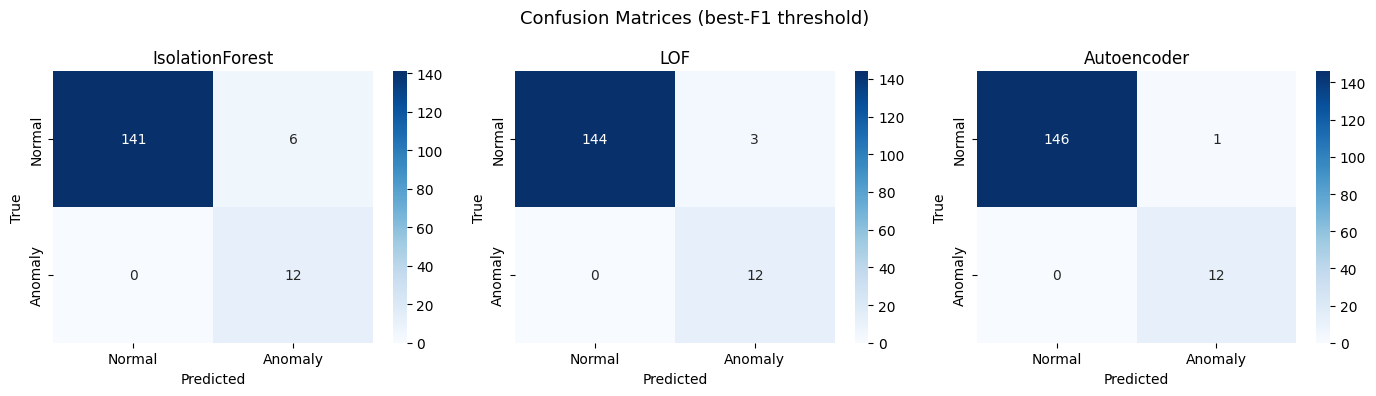

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Confusion matrices
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, scores) in zip(axes, scores_dict.items()):
    thr = thresholds[name]
    y_pred = (scores >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Normal","Anomaly"], yticklabels=["Normal","Anomaly"])
    ax.set_title(name); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.suptitle("Confusion Matrices (best-F1 threshold)", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "confusion_matrices.png"), dpi=120)
plt.show()


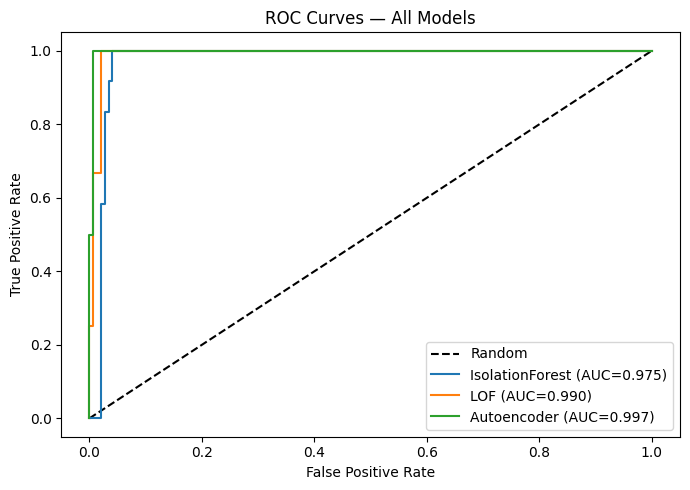

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# ROC curves
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0,1],[0,1],"k--", label="Random")
for name, scores in scores_dict.items():
    fpr_arr, tpr_arr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    ax.plot(fpr_arr, tpr_arr, label=f"{name} (AUC={auc:.3f})")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models"); ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "roc_curves.png"), dpi=120)
plt.show()


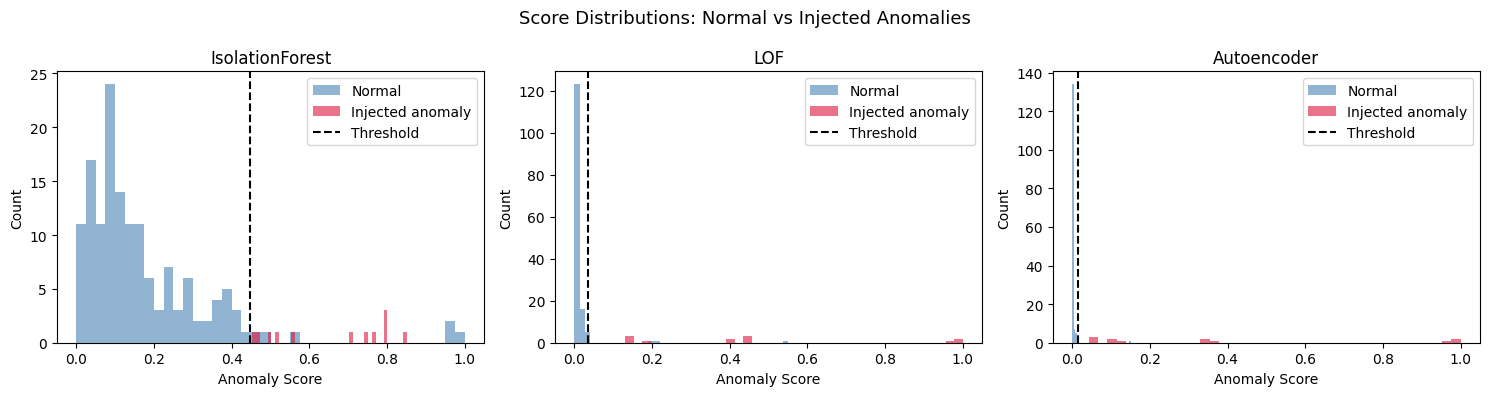

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# Score distributions (normal vs injected anomalies)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, scores) in zip(axes, scores_dict.items()):
    ax.hist(scores[y_true==0], bins=40, alpha=0.6, color="steelblue", label="Normal")
    ax.hist(scores[y_true==1], bins=40, alpha=0.6, color="crimson",   label="Injected anomaly")
    ax.axvline(thresholds[name], color="black", linestyle="--", label=f"Threshold")
    ax.set_title(name); ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Count"); ax.legend()
fig.suptitle("Score Distributions: Normal vs Injected Anomalies", fontsize=13)
plt.tight_layout()
plt.savefig(str(REPORTS_DIR / "score_distributions.png"), dpi=120)
plt.show()


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# System performance metrics
# ─────────────────────────────────────────────────────────────────────────────
print("\n── System Performance Metrics ─────────────────────────────────────")
sys_rows = []
for name, elapsed in times_dict.items():
    throughput = n / elapsed
    mem_mb = proc.memory_info().rss / 1024**2
    print(f"  {name:18s}  latency={elapsed:.4f}s  throughput={throughput:,.0f} rows/s  RSS={mem_mb:.1f} MB")
    sys_rows.append({"model": name, "latency_s": round(elapsed,4),
                     "throughput_rows_per_s": int(throughput), "rss_mb": round(mem_mb,1)})

sys_df = pd.DataFrame(sys_rows)
sys_df.to_csv(str(REPORTS_DIR / "system_metrics.csv"), index=False)
print("\nsystem_metrics.csv saved → reports/")
sys_df



── System Performance Metrics ─────────────────────────────────────
  IsolationForest     latency=0.0924s  throughput=1,721 rows/s  RSS=296.0 MB
  LOF                 latency=0.0030s  throughput=52,306 rows/s  RSS=296.0 MB
  Autoencoder         latency=0.0991s  throughput=1,604 rows/s  RSS=296.0 MB

system_metrics.csv saved → reports/


,model,latency_s,throughput_rows_per_s,rss_mb
0,IsolationForest,0.0924,1720,296.0
1,LOF,0.0030,52306,296.0
2,Autoencoder,0.0991,1604,296.0


## Formulas used

**TP** = predicted anomaly ∧ truly anomaly  
**FP** = predicted anomaly ∧ truly normal  
**TN** = predicted normal ∧ truly normal  
**FN** = predicted normal ∧ truly anomaly  

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

$$\text{FPR} = \frac{FP}{FP + TN}$$

**AUC-ROC** is computed by `sklearn.metrics.roc_auc_score(y_true, scores)` using the continuous anomaly score (not the binary prediction).
